In [ ]:
import konlpy, gensim, sklearn, seaborn, numpy as np, matplotlib.pyplot as plt
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from pathlib import Path
import os, re

print("konlpy :", konlpy.__version__)
print("gensim :", gensim.__version__)
print("sklearn:", sklearn.__version__)
print("seaborn:", seaborn.__version__)

In [2]:
data_dir = Path("./data")
SEED = 42
np.random.seed(SEED)

print(data_dir)

data


In [3]:
def tokenize_file(path: Path, tagger: Okt) -> list[list[str]]:
    """텍스트 파일을 줄 단위로 읽어 명사 토큰만 추출"""
    toks = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            words = [w for w, p in tagger.pos(line, norm=True, stem=True)
                     if p == "Noun"]
            if words:
                toks.append(words)
    return toks

def build_w2v(sentences: list[list[str]], dim=64) -> Word2Vec:
    """Word2Vec skip-gram 모델 학습"""
    return Word2Vec(
        sentences,
        vector_size=dim,
        window=3,
        min_count=5,
        sg=1,          # skip-gram
        workers=4,
        seed=SEED,
    )

def top_unique_words(corpus: list[str], labels: list[str],
                     top_k=100, pick=15) -> dict[str, list[str]]:
    """
    • corpus   : 각 문서가 하나의 장르/구분
    • labels   : corpus와 1:1 대응하는 이름
    • return   : {label: [단어 pick개]} (다른 label과 중복 없음)
    """
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)           # (n_doc, n_vocab)
    vocab  = vectorizer.get_feature_names_out()
    idx2tf = [sorted(zip(vec.col, vec.data),
                     key=lambda t: t[1], reverse=True)
              for vec in (X[i].tocoo() for i in range(X.shape[0]))]

    chosen, global_used = {}, set()
    for label, vec in zip(labels, idx2tf):
        words = []
        for idx, _ in vec:
            w = vocab[idx]
            if w not in global_used:
                words.append(w)
                global_used.add(w)
            if len(words) == pick:
                break
        chosen[label] = words
    return chosen

def cosine(u, v):
    """행 단위 코사인 유사도: u:(m,d), v:(n,d) → (m,n)"""
    u_norm = u / np.linalg.norm(u, axis=1, keepdims=True)
    v_norm = v / np.linalg.norm(v, axis=1, keepdims=True)
    return u_norm @ v_norm.T

def s_score(W, A, B):
    """
    WEAT 단일 s(w,A,B) 벡터화 버전
    • W:(k,d) target 행렬
    • A,B:(m,d)/(n,d) attribute 행렬
    """
    return cosine(W, A).mean(axis=1) - cosine(W, B).mean(axis=1)

def weat_score(X, Y, A, B):
    """Effect size (Caliskan+ 2017)"""
    s_X, s_Y = s_score(X, A, B), s_score(Y, A, B)
    return (s_X.mean() - s_Y.mean()) / np.std(np.concatenate([s_X, s_Y]))

In [4]:
genre_paths = sorted(
    p for p in data_dir.glob("synopsis_*.txt")
    if not re.match(r"synopsis_(art|gen)\.txt$", p.name, re.I)
)
genre_names = [
    p.stem.split("_", 1)[1]          # ex) synopsis_thriller → thriller
    for p in genre_paths
]

print(f"▶ 장르 파일 {len(genre_paths)}개 로드:", [n for n in genre_names])

▶ 장르 파일 21개 로드: ['SF', 'action', 'adult', 'adventure', 'animation', 'comedy', 'crime', 'documentary', 'drama', 'etc', 'family', 'fantasy', 'historical', 'horror', 'musical', 'mystery', 'romance', 'show', 'thriller', 'war', 'western']


- 토큰화

In [ ]:
okt = Okt()
def tokenize_file(path, tagger):
    toks = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            words = [
                w for w, pos in tagger.pos(line, norm=True, stem=True)
                if pos == "Noun"
            ]
            if words:
                toks.append(words)
    return toks

genre_tokens = [tokenize_file(p, okt) for p in genre_paths]

# art / general
art_tokens = tokenize_file(data_dir / "synopsis_art.txt", okt)
gen_tokens = tokenize_file(data_dir / "synopsis_gen.txt", okt)

- Word2Vec 학습 (skip-gram, dim=100)

In [ ]:
sentences = sum(genre_tokens, []) + art_tokens + gen_tokens
print(f"학습 문장 수: {len(sentences):,}")

model = build_w2v(sentences, dim=100)
wv = model.wv
print("✓ Word2Vec 학습 완료")

In [51]:
model.wv.most_similar(positive=['사랑'])

[('삼각관계', 0.6393156051635742),
 ('짊어지', 0.6282990574836731),
 ('연애관', 0.6264605522155762),
 ('고하', 0.6201794743537903),
 ('존경심', 0.6187978982925415),
 ('파란만장', 0.6178041696548462),
 ('소울메이트', 0.6159695386886597),
 ('스팬리', 0.6110579371452332),
 ('토마슈', 0.6097127795219421),
 ('나비문신', 0.6069650053977966)]

In [52]:
model.wv.most_similar(positive=['연극'])

[('대본', 0.7335901856422424),
 ('스탭들', 0.7083362936973572),
 ('제법', 0.7032215595245361),
 ('햄릿', 0.697533369064331),
 ('삽화', 0.6846552491188049),
 ('키아로스타미', 0.678925633430481),
 ('출연자', 0.6702054142951965),
 ('송년회', 0.6648511290550232),
 ('에로영화', 0.6625855565071106),
 ('압바스', 0.6616816520690918)]

- target 단어(art / gen) 선정

In [ ]:
art_corpus = [" ".join(sum(art_tokens, []))]
gen_corpus = [" ".join(sum(gen_tokens, []))]

targets = top_unique_words(
    art_corpus + gen_corpus,
    ["art", "gen"],
    top_k=500, pick=15          # 필요 시 pick 조정
)

target_art = [w for w in targets["art"] if w in wv]
target_gen = [w for w in targets["gen"] if w in wv]
print("Art targets:", target_art)
print("Gen targets:", target_gen, "\n")

X = np.array([wv[w] for w in target_art])
Y = np.array([wv[w] for w in target_gen])

- attribute 단어(장르별) 선정

### 중복 제거 매커니즘 (top_unique_words 함수 참고)
- global_used 전역 집합을 설정해 한 단어가 하나의 label만 가지도록 관리
- '사과'라는 단어가 장르 A에 먼저 들어가면, 장르 B부터는 skip
- 다른 장르간의 중복 단어는 모두 해결, 단일 장르에서 같은 토큰은 TF-IDF 벡터에 1번만 존재하므로 고려 X
- 공포 vs 호러와 같이 토큰은 다르지만 의미가 겹치는 것은 반영 X
- 일부 장르에서는 인물 이름과 같은 고유 명사들이 존재

In [47]:
genre_corpus = [" ".join(sum(tok, [])) for tok in genre_tokens]

attr_words = top_unique_words(
    genre_corpus,
    genre_names,
    top_k=800, pick=15
)

attr_vecs = {}
for g, ws in attr_words.items():
    valid = [w for w in ws if w in wv]
    attr_vecs[g] = np.array([wv[w] for w in valid]) if valid else None
    print(f"{g:<12}: {valid}")

SF          : ['위해', '자신', '지구', '시작', '사람', '인류', '인간', '미래', '우주', '그녀', '로봇', '세계', '모든', '박사', '우주선']
action      : ['조직', '사건', '경찰', '전쟁', '목숨', '사실', '친구', '가족', '요원', '임무', '범죄', '살인', '한편', '아버지', '복수']
adult       : ['남편', '마사지', '섹스', '관계', '영화', '정사', '남자', '여자', '유부녀', '마음', '사랑', '에피소드', '그린', '아내', '다시']
adventure   : ['마을', '아이', '여행', '앤트', '세상', '모험', '비밀', '대한', '이야기', '소년', '여정', '모두', '발견', '영화제', '옥자']
animation   : ['애니메이션', '국제', '인디애니페스트', '페스티벌', '서울', '소녀', '애니', '단편', '부문', '과연', '작품', '만화', '도롱', '부천', '우리']
comedy      : ['인생', '생각', '결혼', '엄마', '서로', '생활', '다른', '코미디', '감독', '아들', '때문', '바로', '시간', '최고', '사고']
crime       : ['마약', '형사', '살해', '수사', '한길수', '범인', '계획', '은행', '작전', '동료', '보스', '미국', '상황', '마피아', '점점']
documentary : ['다큐', '다큐멘터리', '통해', '여성', '한국', '환경', '사회', '모습', '노동자', '가장', '기록', '역사', '음악', '명의', '카메라']
drama       : ['사이', '연출', '어머니', '하나', '학교', '독립', '간다', '기억', '순간', '부산', '현실', '일상', '의도', '죽음', '할머니']
etc         : ['뉴미디어', '아시아

- WEAT matrix 계산

In [48]:
n = len(genre_names)
matrix = np.full((n, n), np.nan)    # NaN으로 초기화

for i in range(n - 1):
    for j in range(i + 1, n):
        A, B = attr_vecs[genre_names[i]], attr_vecs[genre_names[j]]
        if A is not None and B is not None:
            matrix[i, j] = weat_score(X, Y, A, B)

n = matrix.shape[0]
i, j = np.triu_indices(n, k=1)
matrix[j, i] = -matrix[i, j]     # 대각선은 그대로 NaN 또는 0

- 히트맵 시각화

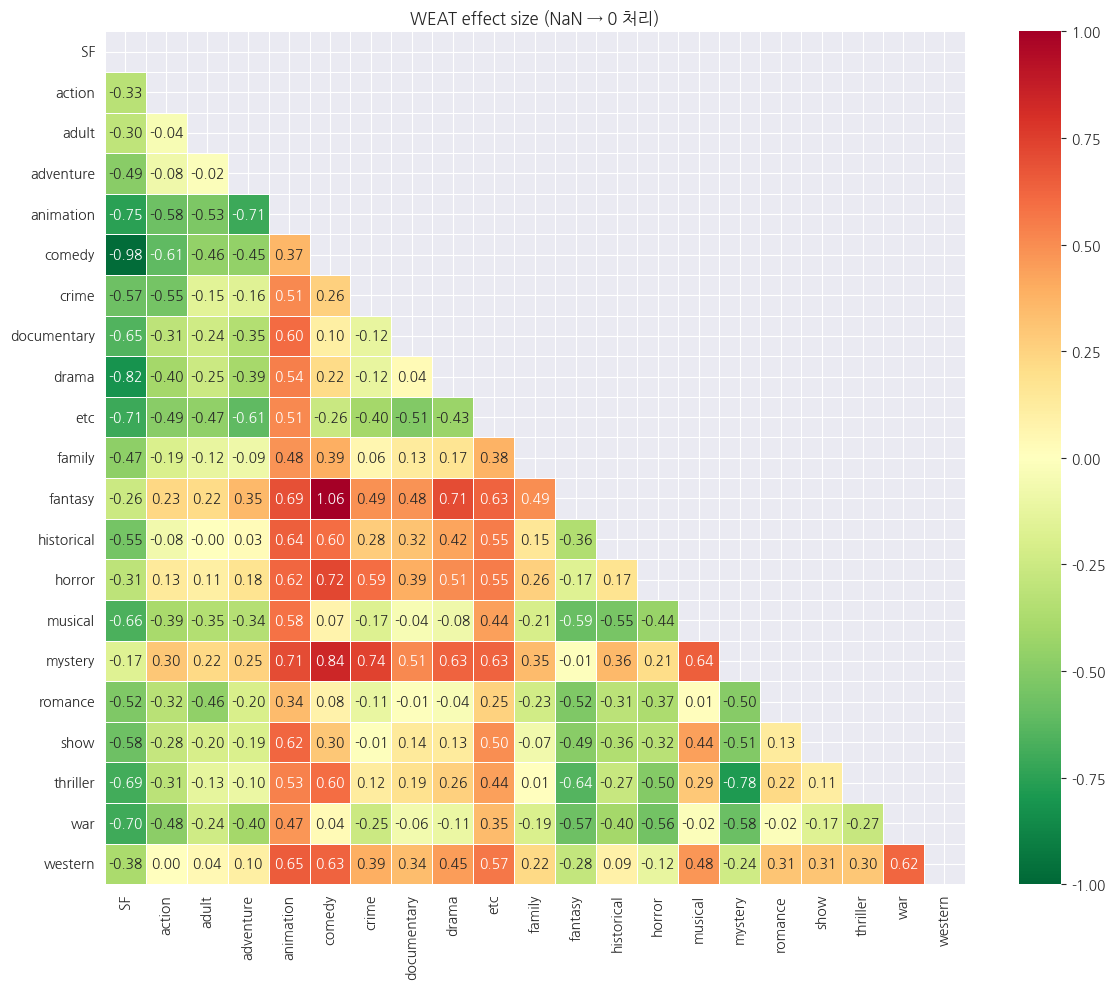

In [53]:
import seaborn as sns, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))  # 위쪽만 보이게(하삼각 가리기)
ax = sns.heatmap(
    matrix,
    mask=mask,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    xticklabels=genre_names,
    yticklabels=genre_names,
    vmin=-1, vmax=1              # 0이 가운데(흰색)로 보이도록 범위 고정
)

ax.set_title("WEAT effect size (NaN → 0 처리)")
plt.tight_layout()
plt.show()

- Adult, Action 모두 예술/일반과 관련이 없음. 점수는 -0.04로 정상적인 점수가 나옴
- mystery, fantasy 또한 마찬가지로 -0.01로 합리적인 점수가 나옴